# Assignment 3 - Transfer Learning with ResNet on BF and FL Images

The target is `Diagnosis`, where `1` means cancer and `0` means healthy.

## 1. Imports and Setup

Required Packages: 
```bash
pip install torch torchvision pandas matplotlib seaborn pillow
```

In [1]:
import csv
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm
from paired_cell_dataset import PairedCellDataset
from paired_transforms import AugmentedPairTransform, BasePairTransform

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
DEVICE

device(type='mps')

In [2]:
ROOT = Path.cwd()
TRAIN_CSV = ROOT / 'train.csv'
SAMPLE_SUBMISSION_CSV = ROOT / 'sampleSubmission.csv'
BF_TRAIN_DIR = ROOT / 'BF' / 'train'
BF_TEST_DIR = ROOT / 'BF' / 'test'
FL_TRAIN_DIR = ROOT / 'FL' / 'train'
FL_TEST_DIR = ROOT / 'FL' / 'test'

required_paths = [
    TRAIN_CSV,
    SAMPLE_SUBMISSION_CSV,
    BF_TRAIN_DIR,
    BF_TEST_DIR,
    FL_TRAIN_DIR,
    FL_TEST_DIR,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('Missing required paths:\n' + '\n'.join(missing_paths))

print('Workspace root:', ROOT)
print('All required files and folders are available.')

Workspace root: /Users/muhammadaufahelfiandri/Documents/Assignments/Advanced Deep Learning for Image/assignment3
All required files and folders are available.


## 2. Load Data and Basic Information

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
submission_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

num_bf_train = len(list(BF_TRAIN_DIR.glob('*.jpg')))
num_fl_train = len(list(FL_TRAIN_DIR.glob('*.jpg')))
num_bf_test = len(list(BF_TEST_DIR.glob('*.jpg')))
num_fl_test = len(list(FL_TEST_DIR.glob('*.jpg')))

print('train.csv shape:', train_df.shape)
print('sampleSubmission.csv shape:', submission_df.shape)
print('BF train images:', num_bf_train)
print('FL train images:', num_fl_train)
print('BF test images:', num_bf_test)
print('FL test images:', num_fl_test)

display(train_df.head())
display(submission_df.head())

train.csv shape: (114302, 2)
sampleSubmission.csv shape: (59040, 2)
BF train images: 114302
FL train images: 114302
BF test images: 59040
FL test images: 59040


,Name,Diagnosis
0,pat_03_image_1.jpg,1
1,pat_03_image_2.jpg,1
2,pat_03_image_3.jpg,1
3,pat_03_image_4.jpg,1
4,pat_03_image_5.jpg,1


,Name,Diagnosis
0,image_1.jpg,0.5
1,image_2.jpg,0.5
2,image_3.jpg,0.5
3,image_4.jpg,0.5
4,image_5.jpg,0.5


In [4]:
label_counts = train_df['Diagnosis'].value_counts().sort_index()
class_names = {0: 'Healthy', 1: 'Cancer'}

summary_df = pd.DataFrame({
    'Class': [class_names[idx] for idx in label_counts.index],
    'Count': label_counts.values,
    'Percentage': (label_counts.values / len(train_df) * 100).round(2),
})
summary_df

,Class,Count,Percentage
0,Healthy,70000,61.24
1,Cancer,44302,38.76


## 3. Visualization

/var/folders/bn/w4ms4n5n7l3czmht6p6ntpjm0000gn/T/ipykernel_21425/2387626009.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Diagnosis', ax=axes[0], palette='viridis')
/var/folders/bn/w4ms4n5n7l3czmht6p6ntpjm0000gn/T/ipykernel_21425/2387626009.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Healthy (0)', 'Cancer (1)'])


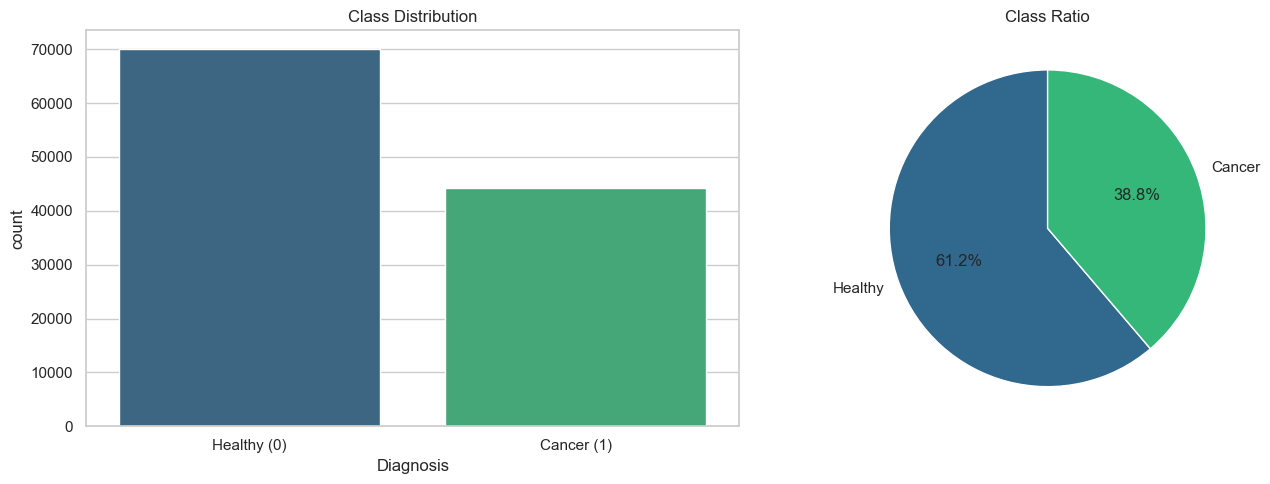

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train_df, x='Diagnosis', ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Healthy (0)', 'Cancer (1)'])

axes[1].pie(
    label_counts.values,
    labels=[class_names[idx] for idx in label_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('viridis', n_colors=2),
)
axes[1].set_title('Class Ratio')

plt.tight_layout()
plt.show()

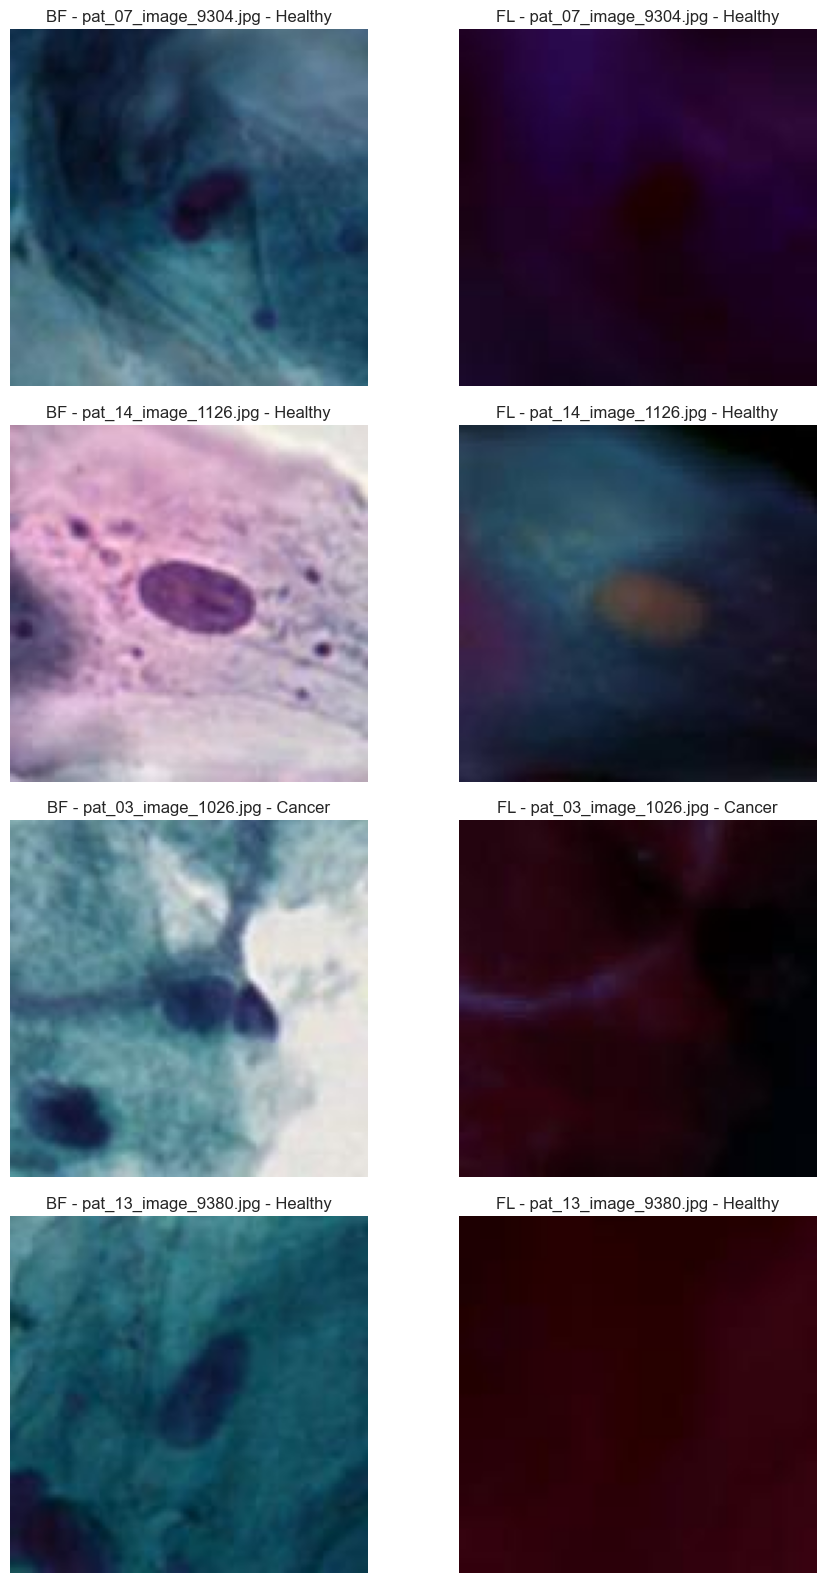

In [6]:
def show_paired_samples(dataframe, bf_dir, fl_dir, num_samples=4, seed=42):
    rng = random.Random(seed)
    sampled_rows = dataframe.sample(num_samples, random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = np.array([axes])

    for row_idx, row in sampled_rows.iterrows():
        image_name = row['Name']
        label = class_names[int(row['Diagnosis'])]

        bf_image = Image.open(bf_dir / image_name).convert('RGB')
        fl_image = Image.open(fl_dir / image_name).convert('RGB')

        axes[row_idx, 0].imshow(bf_image)
        axes[row_idx, 0].set_title(f'BF - {image_name} - {label}')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(fl_image)
        axes[row_idx, 1].set_title(f'FL - {image_name} - {label}')
        axes[row_idx, 1].axis('off')

    plt.tight_layout()
    plt.show()


show_paired_samples(train_df, BF_TRAIN_DIR, FL_TRAIN_DIR, num_samples=4, seed=SEED)

## 4. Train/Validation Split

In [7]:
@dataclass
class Record:
    name: str
    label: float | None


def extract_patient(name: str) -> str:
    # Expect filenames like 'pat_03_image_1.jpg' -> patient 'pat_03'
    if '_image' in name:
        return name.rsplit('_image', 1)[0]
    parts = name.split('_')
    return '_'.join(parts[:2]) if len(parts) >= 2 else parts[0]


def grouped_stratified_split(dataframe, val_ratio=0.15, seed=42):
    """Split by patient (not image) while stratifying by Diagnosis to prevent leakage."""
    df = dataframe.copy()
    df['patient_id'] = df['Name'].map(extract_patient)
    
    # Build patient-level labels (take mode if patient has mixed labels)
    patient_labels = df.groupby('patient_id')['Diagnosis'].agg(lambda x: x.mode().iat[0]).reset_index()
    
    train_patients = []
    val_patients = []
    
    # Stratified split on patients by class
    for label, group in patient_labels.groupby('Diagnosis'):
        patients = group['patient_id'].tolist()
        rng = random.Random(seed)
        rng.shuffle(patients)
        n_val = max(1, int(len(patients) * val_ratio))
        val_patients.extend(patients[:n_val])
        train_patients.extend(patients[n_val:])
    
    train_split = df[df['patient_id'].isin(train_patients)].drop(columns=['patient_id']).reset_index(drop=True)
    val_split = df[df['patient_id'].isin(val_patients)].drop(columns=['patient_id']).reset_index(drop=True)
    
    # Shuffle rows within splits
    train_split = train_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_split = val_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    
    return train_split, val_split


train_split_df, val_split_df = grouped_stratified_split(train_df, val_ratio=0.15, seed=SEED)

print('Training samples:', len(train_split_df))
print('Validation samples:', len(val_split_df))
display(train_split_df['Diagnosis'].value_counts().sort_index())
display(val_split_df['Diagnosis'].value_counts().sort_index())

Training samples: 94302
Validation samples: 20000


Diagnosis
0    60000
1    34302
Name: count, dtype: int64

Diagnosis
0    10000
1    10000
Name: count, dtype: int64

## 5. Dataset and DataLoaders

In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMAGE_SIZE = 224
BATCH_SIZE = 32
USE_AUGMENTATION = True
NUM_WORKERS = 0

In [11]:



base_transform = BasePairTransform(image_size=IMAGE_SIZE)
augmented_transform = AugmentedPairTransform(
    image_size=IMAGE_SIZE,
    hflip_prob=0.5,
    vflip_prob=0.5,
    rotate_prob=0.5,
)
eval_transform = base_transform

test_df = submission_df[['Name']].copy()

train_dataset_original = PairedCellDataset(train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, base_transform, is_test=False)

if USE_AUGMENTATION:
    train_dataset_augmented = PairedCellDataset(train_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, augmented_transform, is_test=False)
    train_dataset = ConcatDataset([train_dataset_original, train_dataset_augmented])
else:
    train_dataset_augmented = None
    train_dataset = train_dataset_original

val_dataset = PairedCellDataset(val_split_df, BF_TRAIN_DIR, FL_TRAIN_DIR, eval_transform, is_test=False)
test_dataset = PairedCellDataset(test_df, BF_TEST_DIR, FL_TEST_DIR, eval_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('USE_AUGMENTATION:', USE_AUGMENTATION)
print('Original train samples:', len(train_dataset_original))
print('Augmented train samples:', 0 if train_dataset_augmented is None else len(train_dataset_augmented))
print('Combined train samples:', len(train_dataset))
print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Test batches:', len(test_loader))

USE_AUGMENTATION: True
Original train samples: 94302
Augmented train samples: 94302
Combined train samples: 188604
Train batches: 5894
Validation batches: 625
Test batches: 1845


In [12]:
bf_batch, fl_batch, label_batch = next(iter(train_loader))
print('BF batch shape:', tuple(bf_batch.shape))
print('FL batch shape:', tuple(fl_batch.shape))
print('Label batch shape:', tuple(label_batch.shape))

BF batch shape: (32, 3, 224, 224)
FL batch shape: (32, 3, 224, 224)
Label batch shape: (32,)


## 6. Model: Two-Stream ImageNet ResNet

In [ ]:
class TwoStreamResNet(nn.Module):
    def __init__(self, backbone_name='resnet50', dropout=0.3):
        super().__init__()

        if backbone_name == 'resnet18':
            backbone_fn = models.resnet18
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            feature_dim = 512
        elif backbone_name == 'resnet34':
            backbone_fn = models.resnet34
            weights = models.ResNet34_Weights.IMAGENET1K_V1
            feature_dim = 512
        elif backbone_name == 'resnet101':
            backbone_fn = models.resnet101
            weights = models.ResNet101_Weights.IMAGENET1K_V2
            feature_dim = 2048
        else:
            backbone_fn = models.resnet50
            weights = models.ResNet50_Weights.IMAGENET1K_V2
            feature_dim = 2048

        self.bf_backbone = backbone_fn(weights=weights)
        self.fl_backbone = backbone_fn(weights=weights)
        self.bf_backbone.fc = nn.Identity()
        self.fl_backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(feature_dim * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
        )

    def forward(self, bf_images, fl_images):
        bf_features = self.bf_backbone(bf_images)
        fl_features = self.fl_backbone(fl_images)
        fused = torch.cat([bf_features, fl_features], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

    def set_backbone_trainable(self, trainable):
        for module in [self.bf_backbone, self.fl_backbone]:
            for param in module.parameters():
                param.requires_grad = trainable


model = TwoStreamResNet(backbone_name='resnet18', dropout=0.3).to(DEVICE)
model

TwoStreamResNet(
  (bf_backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, ep

## 7. Loss, Metrics, and Training Utilities

In [16]:
def run_epoch(model, loader, criterion, optimizer=None, desc='train', epoch=0, phase='train', start_batch_index=0):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    all_targets = []
    all_probs = []
    all_preds = []
    batch_history = []

    progress = tqdm(loader, total=len(loader), desc=desc, leave=False, dynamic_ncols=True)

    for step, (bf_images, fl_images, labels) in enumerate(progress, start=1):
        bf_images = bf_images.to(DEVICE, non_blocking=True)
        fl_images = fl_images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                logits = model(bf_images, fl_images)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                if USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        targets = labels.detach().cpu().numpy()
        preds = (probs >= 0.5).astype(np.int64)

        losses.append(loss.item())
        all_targets.extend(targets.tolist())
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())

        batch_accuracy = float(np.mean(preds == targets.astype(np.int64)))
        running_loss = float(np.mean(losses))
        running_accuracy = float(np.mean(np.array(all_preds) == np.array(all_targets, dtype=np.int64)))
        running_auc = binary_auc_score(all_targets, all_probs)
        global_batch = start_batch_index + step

        batch_history.append({
            'epoch': epoch,
            'phase': phase,
            'batch_in_epoch': step,
            'global_batch': global_batch,
            'batch_loss': float(loss.item()),
            'batch_accuracy': batch_accuracy,
            'running_loss': running_loss,
            'running_accuracy': running_accuracy,
            'running_auc': running_auc,
        })

        if step % 20 == 0 or step == len(loader):
            progress.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_accuracy:.4f}", auc=f"{running_auc:.4f}")

    accuracy = float(np.mean(np.array(all_preds) == np.array(all_targets, dtype=np.int64)))
    auc = binary_auc_score(all_targets, all_probs)

    summary = {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy,
        'auc': auc,
    }

    return summary, batch_history


def predict(model, loader):
    model.eval()
    image_names = []
    probabilities = []

    with torch.no_grad():
        progress = tqdm(loader, total=len(loader), desc='predict', leave=False, dynamic_ncols=True)
        for bf_images, fl_images, names in progress:
            bf_images = bf_images.to(DEVICE, non_blocking=True)
            fl_images = fl_images.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', enabled=USE_AMP):
                logits = model(bf_images, fl_images)

            probs = torch.sigmoid(logits).cpu().numpy().tolist()
            image_names.extend(names)
            probabilities.extend(float(p) for p in probs)

    return image_names, probabilities

## 8. Training

In [17]:
EPOCHS = 10
LEARNING_RATE = 1e-4
FREEZE_BACKBONE_EPOCHS = 5
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / 'best_resnet_transfer.pt'


In [18]:
def binary_auc_score(targets, probabilities):
    targets = np.asarray(targets, dtype=np.int64)
    probabilities = np.asarray(probabilities, dtype=np.float64)

    positives = int(targets.sum())
    negatives = int(len(targets) - positives)
    if positives == 0 or negatives == 0:
        return float('nan')

    order = np.argsort(probabilities, kind='mergesort')
    sorted_probs = probabilities[order]
    sorted_targets = targets[order]

    rank_sum = 0.0
    start = 0
    n = len(sorted_probs)
    while start < n:
        end = start + 1
        while end < n and sorted_probs[end] == sorted_probs[start]:
            end += 1
        avg_rank = (start + end - 1) / 2.0 + 1.0
        positives_in_group = int(sorted_targets[start:end].sum())
        rank_sum += positives_in_group * avg_rank
        start = end

    return float((rank_sum - positives * (positives + 1) / 2.0) / (positives * negatives))


train_label_counts = train_split_df['Diagnosis'].value_counts().to_dict()
pos_weight_value = train_label_counts[0] / train_label_counts[1]

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# AMP is currently enabled only on CUDA; MPS/CPU run in full precision.
USE_AMP = DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler(device='cuda', enabled=USE_AMP)

print('Positive class weight:', round(pos_weight_value, 4))
print('Device:', DEVICE)
print('AMP enabled:', USE_AMP)

Positive class weight: 1.7492
Device: mps
AMP enabled: False


In [ ]:
history = []
batch_history = []
best_val_auc = -math.inf
best_epoch = 0
epochs_without_improvement = 0
train_batch_offset = 0
val_batch_offset = 0

for epoch in range(1, EPOCHS + 1):
    model.set_backbone_trainable(epoch > FREEZE_BACKBONE_EPOCHS)

    start_time = time.time()
    train_metrics, train_batch_metrics = run_epoch(
        model, train_loader, criterion, optimizer, desc=f'E{epoch:02d} train', epoch=epoch, phase='train', start_batch_index=train_batch_offset
    )
    val_metrics, val_batch_metrics = run_epoch(
        model, val_loader, criterion, optimizer=None, desc=f'E{epoch:02d} val', epoch=epoch, phase='val', start_batch_index=val_batch_offset
    )
    batch_history.extend(train_batch_metrics)
    batch_history.extend(val_batch_metrics)
    train_batch_offset += len(train_batch_metrics)
    val_batch_offset += len(val_batch_metrics)
    scheduler.step()
    epoch_time = time.time() - start_time

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_auc': train_metrics['auc'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_auc': val_metrics['auc'],
        'epoch_time_sec': epoch_time,
    }
    history.append(row)

    prev_best_val_auc = best_val_auc
    improved = not math.isnan(val_metrics['auc']) and val_metrics['auc'] > best_val_auc
    if improved:
        improvement = val_metrics['auc'] - prev_best_val_auc if prev_best_val_auc > -math.inf else float('nan')
        best_val_auc = val_metrics['auc']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_auc': best_val_auc,
            'history': history,
            'batch_history': batch_history,
        }, CHECKPOINT_PATH)
        print('Saved best model to', CHECKPOINT_PATH)
    else:
        improvement = val_metrics['auc'] - prev_best_val_auc if prev_best_val_auc > -math.inf and not math.isnan(val_metrics['auc']) else float('nan')
        epochs_without_improvement += 1

    lr_now = optimizer.param_groups[0]['lr']
    if improved:
        status = 'IMPROVED' if math.isnan(improvement) else f'IMPROVED (+{improvement:.4f})'
    else:
        status = 'NO IMPROVEMENT' if math.isnan(improvement) else f'NO IMPROVEMENT ({improvement:.4f})'

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} train_auc={train_metrics['auc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} val_auc={val_metrics['auc']:.4f} | "
        f"best_val_auc={best_val_auc:.4f} (epoch {best_epoch}) | "
        f"status={status} | no_improve={epochs_without_improvement} | "
        f"lr={lr_now:.2e} | time={epoch_time:.1f}s"
    )

history_df = pd.DataFrame(history)
batch_history_df = pd.DataFrame(batch_history)
display(history_df)
batch_history_df.head()

E01 train:   0%|          | 0/5894 [00:00<?, ?it/s]

Saved best model to /Users/muhammadaufahelfiandri/Documents/Assignments/Advanced Deep Learning for Image/assignment3/outputs/best_resnet_transfer.pt
Epoch 01/10 | train_loss=0.3111 train_acc=0.8968 train_auc=0.9638 | val_loss=1.2111 val_acc=0.6007 val_auc=0.6405 | best_val_auc=0.6405 (epoch 1) | status=IMPROVED | no_improve=0 | lr=9.76e-05 | time=1922.1s


Saved best model to /Users/muhammadaufahelfiandri/Documents/Assignments/Advanced Deep Learning for Image/assignment3/outputs/best_resnet_transfer.pt
Epoch 02/10 | train_loss=0.2408 train_acc=0.9223 train_auc=0.9783 | val_loss=1.0371 val_acc=0.6468 val_auc=0.6952 | best_val_auc=0.6952 (epoch 2) | status=IMPROVED (+0.0547) | no_improve=0 | lr=9.05e-05 | time=1837.6s


E03 train:  65%|██████▍   | 3808/5894 [16:32<10:44,  3.24it/s, acc=0.9301, auc=0.9820, loss=0.2193]

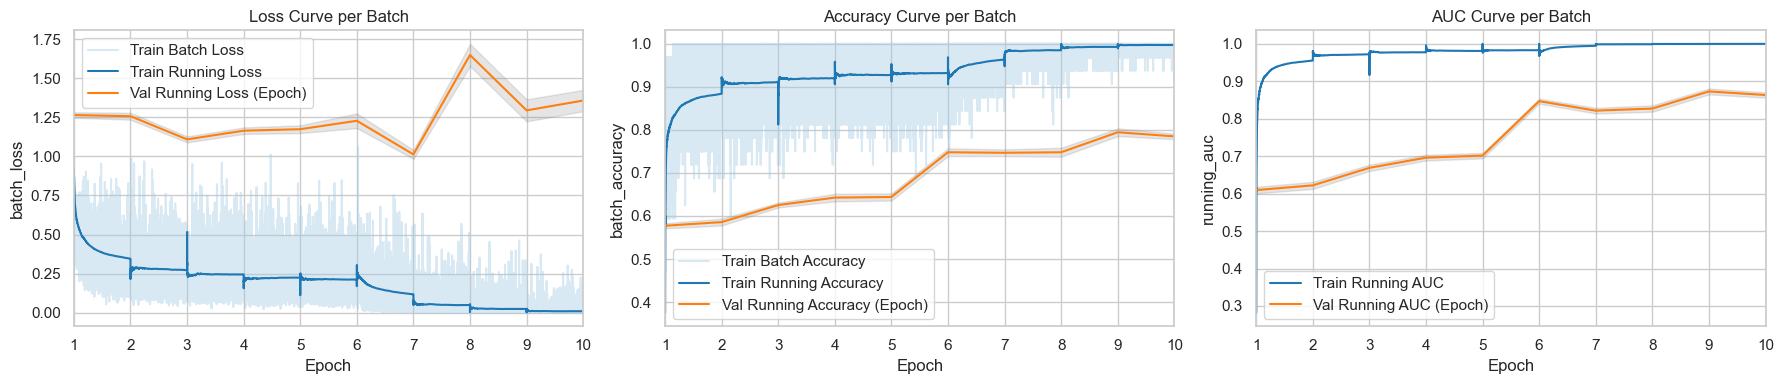

In [ ]:
train_batch_df = batch_history_df[batch_history_df['phase'] == 'train'].copy()
val_batch_df = batch_history_df[batch_history_df['phase'] == 'val'].copy()

# Keep every batch point, but express x as fractional epoch position
train_batches_per_epoch = train_batch_df.groupby('epoch')['batch_in_epoch'].transform('max').clip(lower=1)
val_batches_per_epoch = val_batch_df.groupby('epoch')['batch_in_epoch'].transform('max').clip(lower=1)
train_batch_df['epoch_x'] = (train_batch_df['epoch'] - 1) + (train_batch_df['batch_in_epoch'] - 1) / train_batches_per_epoch
val_batch_df['epoch_x'] = (val_batch_df['epoch'] - 1) + (val_batch_df['batch_in_epoch'] - 1) / val_batches_per_epoch

# Validation lines per epoch with gray uncertainty bands (mean +/- std)
val_epoch_df = val_batch_df.groupby('epoch', as_index=False).agg(
    val_loss_mean=('running_loss', 'mean'),
    val_loss_std=('running_loss', 'std'),
    val_acc_mean=('running_accuracy', 'mean'),
    val_acc_std=('running_accuracy', 'std'),
    val_auc_mean=('running_auc', 'mean'),
    val_auc_std=('running_auc', 'std'),
)
val_epoch_df = val_epoch_df.fillna(0.0)
val_epoch_df['epoch_x'] = val_epoch_df['epoch'] - 1

TRAIN_BATCH_COLOR = '#9ecae1'
TRAIN_RUNNING_COLOR = '#1f77b4'
VAL_RUNNING_COLOR = '#ff7f0e'

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.lineplot(data=train_batch_df, x='epoch_x', y='batch_loss', ax=axes[0], label='Train Batch Loss', alpha=0.40, color=TRAIN_BATCH_COLOR)
sns.lineplot(data=train_batch_df, x='epoch_x', y='running_loss', ax=axes[0], label='Train Running Loss', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_loss_mean', ax=axes[0], label='Val Running Loss', color=VAL_RUNNING_COLOR)
axes[0].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_loss_mean'] - val_epoch_df['val_loss_std'],
    val_epoch_df['val_loss_mean'] + val_epoch_df['val_loss_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[0].set_title('Loss Curve per Batch')
axes[0].set_xlabel('Epoch')

sns.lineplot(data=train_batch_df, x='epoch_x', y='batch_accuracy', ax=axes[1], label='Train Batch Accuracy', alpha=0.40, color=TRAIN_BATCH_COLOR)
sns.lineplot(data=train_batch_df, x='epoch_x', y='running_accuracy', ax=axes[1], label='Train Running Accuracy', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_acc_mean', ax=axes[1], label='Val Running Accuracy', color=VAL_RUNNING_COLOR)
axes[1].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_acc_mean'] - val_epoch_df['val_acc_std'],
    val_epoch_df['val_acc_mean'] + val_epoch_df['val_acc_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[1].set_title('Accuracy Curve per Batch')
axes[1].set_xlabel('Epoch')

sns.lineplot(data=train_batch_df, x='epoch_x', y='running_auc', ax=axes[2], label='Train Running AUC', color=TRAIN_RUNNING_COLOR)
sns.lineplot(data=val_epoch_df, x='epoch_x', y='val_auc_mean', ax=axes[2], label='Val Running AUC', color=VAL_RUNNING_COLOR)
axes[2].fill_between(
    val_epoch_df['epoch_x'],
    val_epoch_df['val_auc_mean'] - val_epoch_df['val_auc_std'],
    val_epoch_df['val_auc_mean'] + val_epoch_df['val_auc_std'],
    color='gray', alpha=0.20, label='Val Variability'
)
axes[2].set_title('AUC Curve per Batch')
axes[2].set_xlabel('Epoch')

if not history_df.empty:
    max_epoch = int(history_df['epoch'].max())
    epoch_ticks = np.arange(0, max_epoch, 1)
    epoch_labels = np.arange(1, max_epoch + 1, 1)
    for ax in axes:
        ax.set_xticks(epoch_ticks)
        ax.set_xticklabels(epoch_labels)
        ax.set_xlim(left=0, right=max(float(max_epoch - 1), 0.0))

plt.tight_layout()
plt.show()

In [70]:
import numpy as np
from matplotlib import pyplot as plt

def training_curve_plot(title, train_costs, test_costs, train_accuracy, test_accuracy, batch_size, learning_rate, num_epochs, elapsed, filename = "./Figures/training_curve.png"):
    # Plot training curves in a format recomended for Hand-in assignment 1 and 2
    #
    # Input
    # title - title for the plot
    # train_costs - Array of training costs (per batch)
    # test_costs - Array of test costs (per epoch)
    # train_accuracies - Array of training accuracies (per batch)
    # test_accuracies - Array of test accuracies (per epoch)
    # batch_size - batch size for training data used during training
    # num_epochs - Number of epochs used during training
    # elapsed - Time elapsed in seconds during training

    lg=18
    md=13
    sm=9
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, y=1.15, fontsize=lg)    
    elapsed_min, elapsed_sec = divmod(elapsed, 60)
    sub = f'|  Batch size:{batch_size}  |  Learning rate:{learning_rate} | Number of Epochs:{num_epochs} | Training time: {elapsed_min:.0f} min {elapsed_sec:.1f} sec |'
    fig.text(0.5, 0.99, sub, ha='center', fontsize=md)

    x_train = np.arange(1, len(train_costs) + 1)
    batches_per_epoch = len(train_costs) / max(len(test_costs), 1)
    x_test = np.arange(1, len(test_costs) + 1) * batches_per_epoch

    axs[0].plot(x_train, train_costs, label=f'Final train cost: {train_costs[-1]:.4f}')
    axs[0].plot(x_test, test_costs, label=f'Final test cost: {test_costs[-1]:.4f}')

    # Mark optimal point (minimum test cost)
    min_test_cost_idx = np.argmin(test_costs)
    opt_x = x_test[min_test_cost_idx]
    opt_y = test_costs[min_test_cost_idx]
    axs[0].plot(opt_x, opt_y, 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2,
                label='Optimal')
    # Add dashed lines to axes
    axs[0].plot([opt_x, opt_x], [axs[0].get_ylim()[0], opt_y], 'r--', linewidth=1, alpha=0.7)
    axs[0].plot([axs[0].get_xlim()[0], opt_x], [opt_y, opt_y], 'r--', linewidth=1, alpha=0.7)
    # Add text annotation near the optimal point
    axs[0].annotate(f'Epoch {min_test_cost_idx + 1}\nBatch {opt_x:.0f}\nCost {opt_y:.4f}', 
                    xy=(opt_x, opt_y), xytext=(10, 10), textcoords='offset points',
                    fontsize=sm, color='red', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

    axs[0].set_title('Costs', fontsize=md)
    axs[0].set_xlabel('Epoch', fontsize=md)
    axs[0].set_ylabel('Cost', fontsize=md)
    axs[0].legend(fontsize=sm)
    axs[0].tick_params(axis='both', labelsize=sm)
    # Optionally use a logarithmic y-scale
    #axs[0].set_yscale('log')
    axs[1].plot(x_train, train_accuracy, label=f'Final Train AUC: {100*train_accuracy[-1]:.2f}%')
    axs[1].plot(x_test, test_accuracy, label=f'Final Test AUC: {100*test_accuracy[-1]:.2f}%')

    # Mark optimal point (maximum test accuracy)
    max_test_acc_idx = np.argmax(test_accuracy)
    opt_x = x_test[max_test_acc_idx]
    opt_y = test_accuracy[max_test_acc_idx]
    axs[1].plot(opt_x, opt_y, 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2,
                label='Optimal')
    # Add dashed lines to axes
    axs[1].plot([opt_x, opt_x], [axs[1].get_ylim()[0], opt_y], 'r--', linewidth=1, alpha=0.7)
    axs[1].plot([axs[1].get_xlim()[0], opt_x], [opt_y, opt_y], 'r--', linewidth=1, alpha=0.7)
    # Add text annotation near the optimal point
    axs[1].annotate(f'Epoch {max_test_acc_idx + 1}\nAcc {100*opt_y:.2f}%', 
                    xy=(opt_x, opt_y), xytext=(10, 10), textcoords='offset points',
                    fontsize=sm, color='red', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8))

    axs[1].set_title('AUC', fontsize=md)
    axs[1].set_xlabel('Training Batch', fontsize=md)
    axs[1].set_ylabel('AUC (%)', fontsize=sm)
    axs[1].legend(fontsize=sm)
    axs[1].tick_params(axis='both', labelsize=sm)     

    plt.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.show()

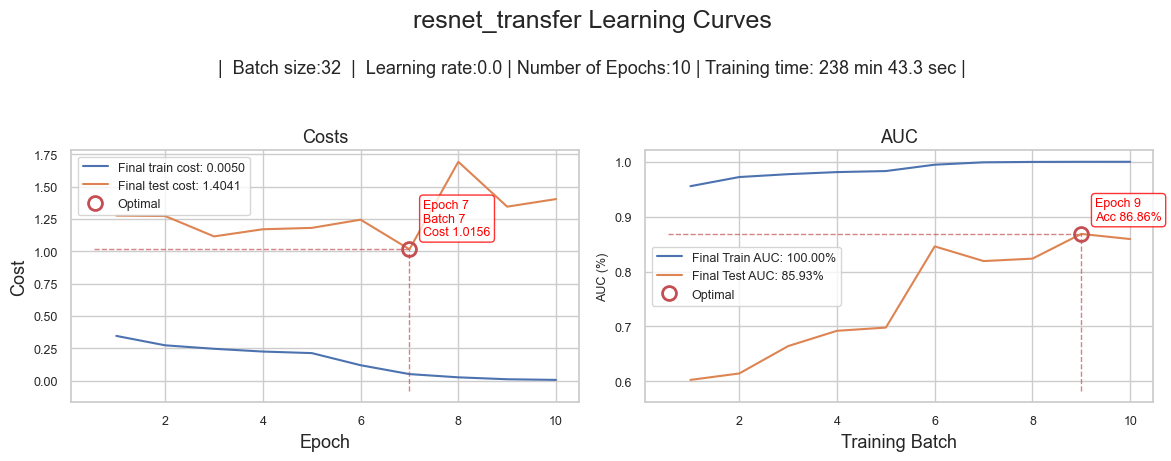

In [ ]:
plot_model_name = 'resnet_transfer'
train_losses = history_df['train_loss'].tolist()
val_losses = history_df['val_loss'].tolist()
train_accuracy = history_df['train_accuracy'].tolist()
val_accuracy = history_df['val_accuracy'].tolist()
train_auc = history_df['train_auc'].tolist()
val_auc = history_df['val_auc'].tolist()

batch_size = BATCH_SIZE
learning_rate = float(LEARNING_RATE)
num_epochs = int(history_df['epoch'].max()) if not history_df.empty else EPOCHS
training_time_seconds = float(history_df['epoch_time_sec'].sum()) if not history_df.empty else 0.0
output_dir = OUTPUT_DIR

training_curve_plot(
    title=f"{plot_model_name} Learning Curves",
    train_costs=train_losses,
    test_costs=val_losses,
    train_accuracy=train_auc,
    test_accuracy=val_auc,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    elapsed=training_time_seconds,
    filename=str(output_dir / f"{plot_model_name}_training_curve.png"),
)

## 9. Testing and Submission

In [ ]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print('Loaded best model with validation AUC:', checkpoint['best_val_auc'])

Loaded best model with validation AUC: 0.9997724461643197


In [ ]:
test_names, test_probabilities = predict(model, test_loader)

submission = pd.DataFrame({
    'Name': test_names,
    'Diagnosis': test_probabilities,
})

submission_path = OUTPUT_DIR / 'submission_notebook_resnet_transfer.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
display(submission.head())

Submission saved to: /Users/muhammadaufahelfiandri/Documents/Assignments/Advanced Deep Learning for Image/assignment3/outputs/submission_notebook_resnet_transfer.csv


,Name,Diagnosis
0,image_1.jpg,1.735178e-06
1,image_2.jpg,4.169218e-07
2,image_3.jpg,2.701030e-05
3,image_4.jpg,1.075755e-06
4,image_5.jpg,3.038064e-04
